<a href="https://www.kaggle.com/code/manohar6143/siamese-animal-dataset?scriptVersionId=241895776" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/animal-image-dataset-cats-dogs-and-foxes/Animal Image Dataset-Cats, Dogs, and Foxes/fox/fox016.jpeg
/kaggle/input/animal-image-dataset-cats-dogs-and-foxes/Animal Image Dataset-Cats, Dogs, and Foxes/fox/fox032.jpg
/kaggle/input/animal-image-dataset-cats-dogs-and-foxes/Animal Image Dataset-Cats, Dogs, and Foxes/fox/fox075.jpg
/kaggle/input/animal-image-dataset-cats-dogs-and-foxes/Animal Image Dataset-Cats, Dogs, and Foxes/fox/fox042.jpg
/kaggle/input/animal-image-dataset-cats-dogs-and-foxes/Animal Image Dataset-Cats, Dogs, and Foxes/fox/fox043.jpg
/kaggle/input/animal-image-dataset-cats-dogs-and-foxes/Animal Image Dataset-Cats, Dogs, and Foxes/fox/fox059.jpg
/kaggle/input/animal-image-dataset-cats-dogs-and-foxes/Animal Image Dataset-Cats, Dogs, and Foxes/fox/fox077.jpg
/kaggle/input/animal-image-dataset-cats-dogs-and-foxes/Animal Image Dataset-Cats, Dogs, and Foxes/fox/fox074.jpg
/kaggle/input/animal-image-dataset-cats-dogs-and-foxes/Animal Image Dataset-Cats, Dogs, and Fox

In [2]:
import os
import random
import torch
import torch.nn as nn
from torchvision import transforms, models
from torch.utils.data import Dataset, DataLoader
from PIL import Image
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import numpy as np

In [3]:
base_data_dir = "/kaggle/input/animal-image-dataset-cats-dogs-and-foxes"

In [4]:
def find_class_folder(base_dir):
    for entry in os.listdir(base_dir):
        full_path = os.path.join(base_dir, entry)
        if os.path.isdir(full_path):
            # Check for at least two class subfolders inside
            subdirs = [d for d in os.listdir(full_path) if os.path.isdir(os.path.join(full_path, d))]
            if len(subdirs) >= 2:
                return full_path
    raise ValueError("Could not find a valid class directory with at least 2 subfolders.")

data_dir = find_class_folder(base_data_dir)
print("Using data_dir:", data_dir)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
image_size = 224
batch_size = 32
margin = 1.0

transform = transforms.Compose([
    transforms.Resize((image_size, image_size)),
    transforms.ToTensor()
])


Using data_dir: /kaggle/input/animal-image-dataset-cats-dogs-and-foxes/Animal Image Dataset-Cats, Dogs, and Foxes


In [5]:
# Load image paths
def get_image_paths(data_dir):
    classes = [d for d in os.listdir(data_dir) if os.path.isdir(os.path.join(data_dir, d))]
    if len(classes) < 2:
        raise ValueError("Need at least 2 classes for Siamese Network training.")
    image_paths = []
    for label in classes:
        class_path = os.path.join(data_dir, label)
        for img in os.listdir(class_path):
            full_path = os.path.join(class_path, img)
            if os.path.isfile(full_path) and img.lower().endswith(('.png', '.jpg', '.jpeg')):
                image_paths.append((full_path, label))
    return image_paths



In [6]:
class SiameseDataset(Dataset):
    def __init__(self, image_paths, transform):  # <-- FIXED
        self.image_paths = image_paths
        self.transform = transform
        self.label_to_images = {}
        for path, label in image_paths:
            self.label_to_images.setdefault(label, []).append(path)

    def __getitem__(self, idx):  # <-- FIXED
        img1_path, label1 = self.image_paths[idx]
        should_get_same_class = random.randint(0, 1)

        if should_get_same_class or len(self.label_to_images) == 1:
            img2_path = random.choice(self.label_to_images[label1])
            label = 1
        else:
            other_labels = [l for l in self.label_to_images if l != label1]
            if not other_labels:
                img2_path = random.choice(self.label_to_images[label1])
                label = 1
            else:
                label2 = random.choice(other_labels)
                img2_path = random.choice(self.label_to_images[label2])
                label = 0

        img1 = self.transform(Image.open(img1_path).convert("RGB"))
        img2 = self.transform(Image.open(img2_path).convert("RGB"))
        return img1, img2, torch.tensor([label], dtype=torch.float32)

    def __len__(self):  # <-- FIXED
        return len(self.image_paths)


In [7]:
class SiameseNetwork(nn.Module):
    def __init__(self):  # <-- FIXED
        super(SiameseNetwork, self).__init__()
        self.cnn = models.resnet18(pretrained=True)
        self.cnn.fc = nn.Linear(self.cnn.fc.in_features, 256)

    def forward_once(self, x):
        return self.cnn(x)

    def forward(self, x1, x2):
        return self.forward_once(x1), self.forward_once(x2)


In [8]:
class ContrastiveLoss(nn.Module):
    def __init__(self, margin):
        super().__init__()
        self.margin = margin

    def forward(self, output1, output2, label):
        dist = nn.functional.pairwise_distance(output1, output2)
        loss = torch.mean(
            (1 - label) * torch.pow(dist, 2) +
            label * torch.pow(torch.clamp(self.margin - dist, min=0.0), 2)
        )
        return loss


In [9]:
# Load data
image_paths = get_image_paths(data_dir)
random.shuffle(image_paths)
train_dataset = SiameseDataset(image_paths, transform)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)


In [10]:
# Train
epochs = 15
model = SiameseNetwork().to(device)
criterion = ContrastiveLoss(margin)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

for epoch in range(epochs):
    model.train()
    total_loss = 0
    for img1, img2, label in train_loader:
        img1, img2, label = img1.to(device), img2.to(device), label.to(device)
        optimizer.zero_grad()
        out1, out2 = model(img1, img2)
        loss = criterion(out1, out2, label)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    print(f"Epoch [{epoch+1}/{epochs}], Loss: {total_loss/len(train_loader):.4f}")


/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth
100%|██████████| 44.7M/44.7M [00:00<00:00, 162MB/s]


Epoch [1/15], Loss: 32.3874
Epoch [2/15], Loss: 15.6311
Epoch [3/15], Loss: 6.1042
Epoch [4/15], Loss: 3.2100
Epoch [5/15], Loss: 1.6767
Epoch [6/15], Loss: 1.0195
Epoch [7/15], Loss: 0.7380
Epoch [8/15], Loss: 0.6551
Epoch [9/15], Loss: 0.5472
Epoch [10/15], Loss: 0.4466
Epoch [11/15], Loss: 0.3702
Epoch [12/15], Loss: 0.3534
Epoch [13/15], Loss: 0.3338
Epoch [14/15], Loss: 0.3518
Epoch [15/15], Loss: 0.2891


Generating t-SNE visualization...


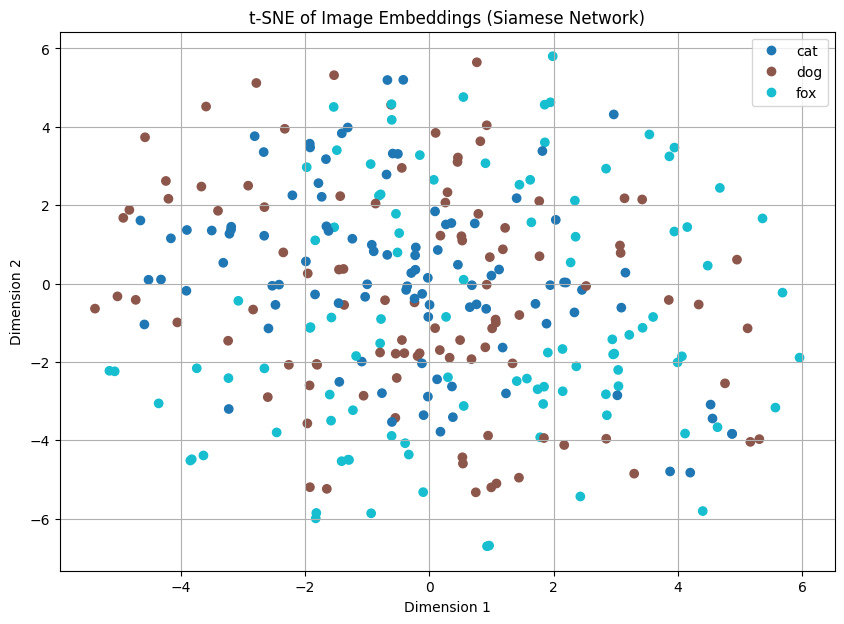

In [11]:
# t-SNE visualization
print("Generating t-SNE visualization...")
model.eval()
sample_size = 300
subset = random.sample(image_paths, min(sample_size, len(image_paths)))
embeddings, labels, label_map = [], [], {}
with torch.no_grad():
    for img_path, label in subset:
        img = transform(Image.open(img_path).convert("RGB")).unsqueeze(0).to(device)
        embedding = model.forward_once(img).cpu().numpy().flatten()
        if label not in label_map:
            label_map[label] = len(label_map)
        embeddings.append(embedding)
        labels.append(label_map[label])
tsne = TSNE(n_components=2, perplexity=30, n_iter=1000, random_state=42)
tsne_results = tsne.fit_transform(np.array(embeddings))
plt.figure(figsize=(10, 7))
scatter = plt.scatter(tsne_results[:, 0], tsne_results[:, 1], c=labels, cmap='tab10')
plt.legend(handles=scatter.legend_elements()[0], labels=label_map.keys())
plt.title("t-SNE of Image Embeddings (Siamese Network)")
plt.xlabel("Dimension 1")
plt.ylabel("Dimension 2")
plt.grid(True)
plt.show()